# Questions 1.2.3 — Independent First Limits

**Setup (from MODAL v1.3):**
- Two independent queues $Q_1$ (ask) and $Q_{-1}$ (bid)
- Constant rates: $\lambda^+ = 1.2$ (add), $\lambda^- = 1.5$ (remove) per ms
- Initial: $Q_1(0) = Q_{-1}(0) = 10$
- Simulate until one hits zero

---

In [1]:
import sys; sys.path.insert(0, '.')
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from model.hitting_times import *

plt.rcParams.update({'figure.figsize': (12, 4), 'font.size': 11,
                      'axes.grid': True, 'grid.alpha': 0.3})

# ── Parameters ────────────────────────────────────────────────────
LP = 1.2        # λ⁺ (additions per ms)
LM = 1.5        # λ⁻ (removals per ms)
MU = LP - LM    # drift = -0.3
SIGMA2 = LP + LM  # variance rate = 2.7
SIGMA = np.sqrt(SIGMA2)
Q0 = 10          # initial queue size

print(f'λ⁺ = {LP}, λ⁻ = {LM}')
print(f'μ = λ⁺ - λ⁻ = {MU}')
print(f'σ² = λ⁺ + λ⁻ = {SIGMA2}, σ = {SIGMA:.4f}')
print(f'Q₁(0) = Q₋₁(0) = {Q0}')

λ⁺ = 1.2, λ⁻ = 1.5
μ = λ⁺ - λ⁻ = -0.30000000000000004
σ² = λ⁺ + λ⁻ = 2.7, σ = 1.6432
Q₁(0) = Q₋₁(0) = 10


## Q0. Simulate until one queue hits zero

Hitting time: T = 13.49 ms
Which hit zero: Q_{"+1" if res.which_hit==1 else "-1"}
Final: Q₁ = 0, Q₋₁ = 13
Number of events: 73


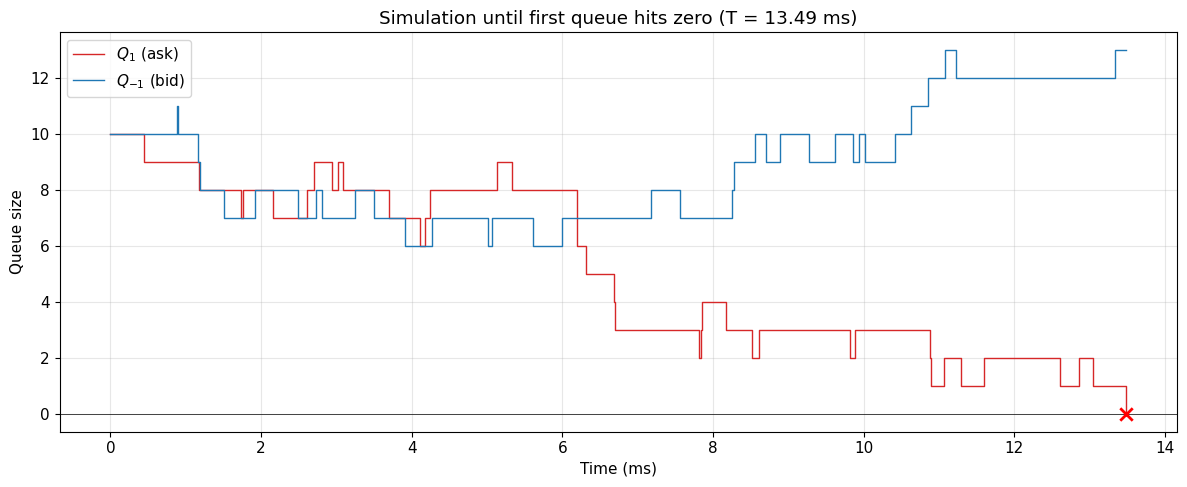

In [2]:
# ── Single simulation with trajectory ────────────────────────────
rng = np.random.default_rng(42)
res = simulate_until_hit_zero(Q0, Q0, LP, LM, rng=rng, record_path=True)

print(f'Hitting time: T = {res.hitting_time:.2f} ms')
print(f'Which hit zero: Q_{{"+1" if res.which_hit==1 else "-1"}}')
print(f'Final: Q₁ = {res.q1_final}, Q₋₁ = {res.q_neg1_final}')
print(f'Number of events: {len(res.times) - 1}')

fig, ax = plt.subplots(figsize=(12, 5))
ax.step(res.times, res.q1_path, where='post', lw=1, color='C3', label='$Q_1$ (ask)')
ax.step(res.times, res.q_neg1_path, where='post', lw=1, color='C0', label='$Q_{-1}$ (bid)')
ax.axhline(0, color='black', lw=0.5)
ax.scatter([res.hitting_time], [0], zorder=5, color='red', s=80, marker='x', linewidths=2)
ax.set_xlabel('Time (ms)')
ax.set_ylabel('Queue size')
ax.set_title(f'Simulation until first queue hits zero (T = {res.hitting_time:.2f} ms)')
ax.legend()
plt.tight_layout()
plt.show()

## Q1. Brownian motion approximation

$Q_i(t)$ is a birth-death process: $+1$ at rate $\lambda^+$, $-1$ at rate $\lambda^-$.

**Key result:** By the diffusion approximation (functional CLT), at large time scales:

$$Q_i(t) \approx Q_i(0) + \mu t + \sigma W(t)$$

where $\mu = \lambda^+ - \lambda^- = -0.3$ and $\sigma^2 = \lambda^+ + \lambda^- = 2.7$.

**Why?** In time $[0, t]$, there are $N^+(t) \sim \text{Poi}(\lambda^+ t)$ additions and  
$N^-(t) \sim \text{Poi}(\lambda^- t)$ removals. So $Q_i(t) = Q_i(0) + N^+(t) - N^-(t)$.

- $E[N^+ - N^-] = (\lambda^+ - \lambda^-)t = \mu t$ → drift
- $\text{Var}[N^+ - N^-] = (\lambda^+ + \lambda^-)t = \sigma^2 t$ → diffusion

By CLT: $(N^+ - N^- - \mu t) / (\sigma \sqrt{t}) \to \mathcal{N}(0, 1)$ → Brownian motion.

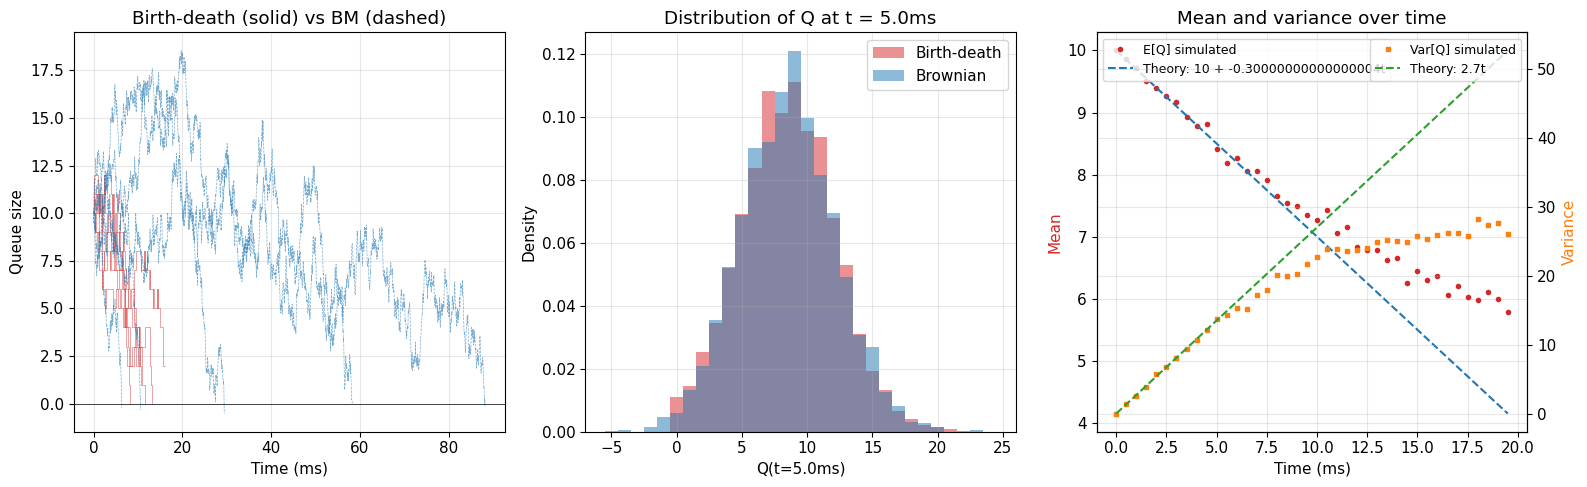

In [3]:
# ── Visual comparison: birth-death vs Brownian ────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

rng = np.random.default_rng(123)

# Panel 1: overlay trajectories
ax = axes[0]
for _ in range(5):
    r = simulate_until_hit_zero(Q0, Q0, LP, LM, rng=rng, record_path=True)
    ax.step(r.times, r.q1_path, where='post', lw=0.5, alpha=0.6, color='C3')

# Overlay Brownian paths
dt_bm = 0.05
for _ in range(5):
    t_bm, times_bm, path_bm = simulate_brownian_until_hit_zero(
        Q0, MU, SIGMA, dt_bm, rng=rng)
    ax.plot(times_bm, path_bm, lw=0.5, alpha=0.6, color='C0', ls='--')

ax.axhline(0, color='black', lw=0.5)
ax.set_xlabel('Time (ms)')
ax.set_ylabel('Queue size')
ax.set_title('Birth-death (solid) vs BM (dashed)')

# Panel 2: distribution of Q(t) at fixed t
ax = axes[1]
t_check = 5.0  # ms
n_samples = 5000
q_bd = []  # birth-death
q_bm = []  # Brownian

for _ in range(n_samples):
    # Birth-death: simulate for t_check time
    q = Q0
    t = 0
    while t < t_check:
        dt = rng.exponential(1.0 / (LP + LM))
        t += dt
        if t < t_check:
            q += 1 if rng.random() < LP / (LP + LM) else -1
            q = max(0, q)
    q_bd.append(q)
    # Brownian
    q_bm.append(Q0 + MU * t_check + SIGMA * rng.normal(0, np.sqrt(t_check)))

bins = np.arange(-5.5, 25.5, 1)
ax.hist(q_bd, bins=bins, density=True, alpha=0.5, label='Birth-death', color='C3')
ax.hist(q_bm, bins=bins, density=True, alpha=0.5, label='Brownian', color='C0')
ax.set_xlabel(f'Q(t={t_check}ms)')
ax.set_ylabel('Density')
ax.set_title(f'Distribution of Q at t = {t_check}ms')
ax.legend()

# Panel 3: mean and variance over time
ax = axes[2]
t_points = np.arange(0, 20, 0.5)
means_bd = []
vars_bd = []
n_mc = 2000
for tp in t_points:
    qs = []
    for _ in range(n_mc):
        q = Q0
        t = 0
        while t < tp:
            dt = rng.exponential(1.0 / (LP + LM))
            t += dt
            if t < tp:
                q += 1 if rng.random() < LP / (LP + LM) else -1
                q = max(0, q)
        qs.append(q)
    means_bd.append(np.mean(qs))
    vars_bd.append(np.var(qs))

ax.plot(t_points, means_bd, 'o', ms=3, color='C3', label='E[Q] simulated')
ax.plot(t_points, Q0 + MU * t_points, '--', color='C0', label=f'Theory: {Q0} + {MU}t')
ax2 = ax.twinx()
ax2.plot(t_points, vars_bd, 's', ms=3, color='C1', label='Var[Q] simulated')
ax2.plot(t_points, SIGMA2 * t_points, '--', color='C2', label=f'Theory: {SIGMA2}t')
ax.set_xlabel('Time (ms)')
ax.set_ylabel('Mean', color='C3')
ax2.set_ylabel('Variance', color='C1')
ax.set_title('Mean and variance over time')
ax.legend(loc='upper left', fontsize=9)
ax2.legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.show()

## Q2. Hitting time distribution: simulation vs Brownian theory

For a Brownian motion $X(t) = x_0 + \mu t + \sigma W(t)$ with $\mu < 0$,  
the first hitting time of 0 follows an **Inverse Gaussian** distribution:

$$f_{T_0}(t) = \frac{x_0}{\sigma \sqrt{2\pi t^3}} \exp\left(-\frac{(x_0 + \mu t)^2}{2\sigma^2 t}\right)$$

with mean $E[T_0] = x_0 / |\mu|$ and variance $\text{Var}[T_0] = x_0 \sigma^2 / |\mu|^3$.

In [4]:
# ── Simulate hitting times (birth-death and Brownian) ─────────────
N_sim = 10000
rng = np.random.default_rng(42)

# Birth-death hitting times (single queue, stop when Q=0)
ht_bd = []
for _ in range(N_sim):
    q = Q0
    t = 0
    while q > 0:
        dt = rng.exponential(1.0 / (LP + LM))
        t += dt
        q += 1 if rng.random() < LP / (LP + LM) else -1
    ht_bd.append(t)
ht_bd = np.array(ht_bd)

# Brownian hitting times (single BM, stop when X≤0)
ht_bm = []
dt_sim = 0.02
for _ in range(N_sim):
    t_hit, _, _ = simulate_brownian_until_hit_zero(Q0, MU, SIGMA, dt_sim, rng=rng)
    ht_bm.append(t_hit)
ht_bm = np.array(ht_bm)

# Theoretical PDF
t_theory = np.linspace(0.1, 150, 1000)
pdf_theory = hitting_time_pdf_brownian(t_theory, Q0, MU, SIGMA)

print(f'Birth-death: mean T = {ht_bd.mean():.2f} ms, std = {ht_bd.std():.2f}')
print(f'Brownian sim: mean T = {ht_bm.mean():.2f} ms, std = {ht_bm.std():.2f}')
print(f'Theory: E[T] = {hitting_time_mean_brownian(Q0, MU):.2f}, '
      f'std = {np.sqrt(hitting_time_variance_brownian(Q0, MU, SIGMA)):.2f}')

Birth-death: mean T = 32.98 ms, std = 31.16
Brownian sim: mean T = 33.51 ms, std = 30.92
Theory: E[T] = 33.33, std = 31.62


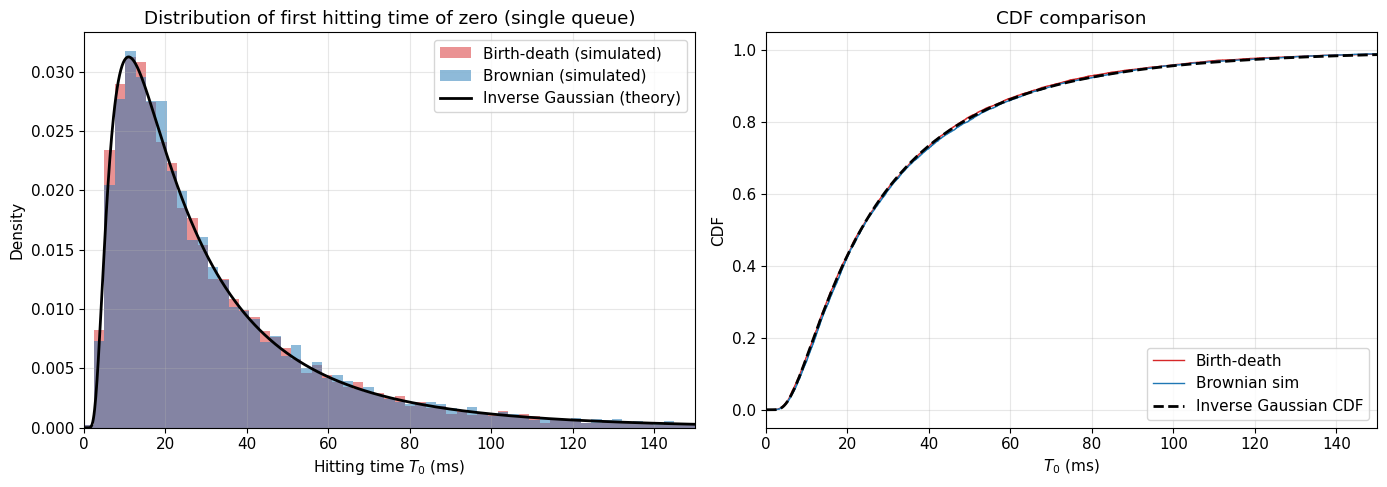

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: PDF comparison
ax = axes[0]
bins = np.linspace(0, 150, 60)
ax.hist(ht_bd, bins=bins, density=True, alpha=0.5, label='Birth-death (simulated)', color='C3')
ax.hist(ht_bm, bins=bins, density=True, alpha=0.5, label='Brownian (simulated)', color='C0')
ax.plot(t_theory, pdf_theory, 'k-', lw=2, label='Inverse Gaussian (theory)')
ax.set_xlabel('Hitting time $T_0$ (ms)')
ax.set_ylabel('Density')
ax.set_title('Distribution of first hitting time of zero (single queue)')
ax.legend()
ax.set_xlim(0, 150)

# Right: CDF comparison
ax = axes[1]
ht_bd_sorted = np.sort(ht_bd)
ht_bm_sorted = np.sort(ht_bm)
ecdf_bd = np.arange(1, N_sim + 1) / N_sim
ecdf_bm = np.arange(1, N_sim + 1) / N_sim
cdf_theory = hitting_time_cdf_brownian(t_theory, Q0, MU, SIGMA)

ax.step(ht_bd_sorted, ecdf_bd, lw=1, color='C3', label='Birth-death')
ax.step(ht_bm_sorted, ecdf_bm, lw=1, color='C0', label='Brownian sim')
ax.plot(t_theory, cdf_theory, 'k--', lw=2, label='Inverse Gaussian CDF')
ax.set_xlabel('$T_0$ (ms)')
ax.set_ylabel('CDF')
ax.set_title('CDF comparison')
ax.legend()
ax.set_xlim(0, 150)

plt.tight_layout()
plt.show()

## Q3. Mean hitting time of zero + confidence interval

For the min of **two independent** queues, we simulate many runs.

In [6]:
# ── Mean hitting time: min(T_Q1, T_Q-1) ──────────────────────────
N_runs = 10000
batch = batch_hitting_times(N_runs, Q0, Q0, LP, LM, seed=42)

E_T_one = hitting_time_mean_brownian(Q0, MU)

print(f'=== Hitting time of min(Q₁, Q₋₁) reaching zero ===')
print(f'  N simulations:  {N_runs}')
print(f'  Mean T:         {batch["mean_T"]:.2f} ms')
print(f'  Std T:          {batch["std_T"]:.2f} ms')
print(f'  95% CI:         [{batch["ci_95"][0]:.2f}, {batch["ci_95"][1]:.2f}] ms')
print(f'  P(Q₁ first):    {batch["prob_q1_first"]:.3f} (should ≈ 0.5 by symmetry)')
print(f'\n  E[T] single queue (BM theory): {E_T_one:.2f} ms')
print(f'  E[min(T₁,T₂)] < E[T₁] as expected')

=== Hitting time of min(Q₁, Q₋₁) reaching zero ===
  N simulations:  10000
  Mean T:         18.63 ms
  Std T:          13.71 ms
  95% CI:         [18.36, 18.90] ms
  P(Q₁ first):    0.505 (should ≈ 0.5 by symmetry)

  E[T] single queue (BM theory): 33.33 ms
  E[min(T₁,T₂)] < E[T₁] as expected


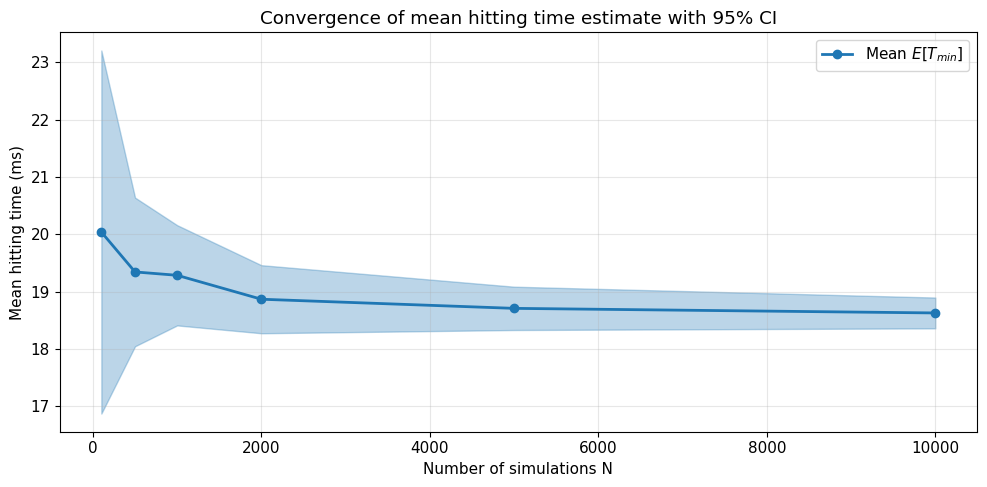

In [7]:
# ── Convergence of CI with N ─────────────────────────────────────
ns = [100, 500, 1000, 2000, 5000, 10000]
means = []
cis = []

for n in ns:
    b = batch_hitting_times(n, Q0, Q0, LP, LM, seed=42)
    means.append(b['mean_T'])
    cis.append(b['ci_95'])

fig, ax = plt.subplots(figsize=(10, 5))
lo = [c[0] for c in cis]
hi = [c[1] for c in cis]
ax.fill_between(ns, lo, hi, alpha=0.3, color='C0')
ax.plot(ns, means, 'o-', color='C0', lw=2, label='Mean $E[T_{min}]$')
ax.set_xlabel('Number of simulations N')
ax.set_ylabel('Mean hitting time (ms)')
ax.set_title('Convergence of mean hitting time estimate with 95% CI')
ax.legend()
plt.tight_layout()
plt.show()

## Q4. Mean hitting time as function of $Q_1(0)$ and $Q_{-1}(0)$

In [8]:
# ── 2D scan: E[T_min] as function of initial conditions ──────────
q_range = np.arange(2, 22, 2)
print(f'Scanning {len(q_range)}x{len(q_range)} = {len(q_range)**2} grid points...')

scan = scan_initial_conditions(q_range, q_range, n_runs=1000,
                                lambda_plus=LP, lambda_minus=LM, seed=42)
print('Done.')

Scanning 10x10 = 100 grid points...
Done.


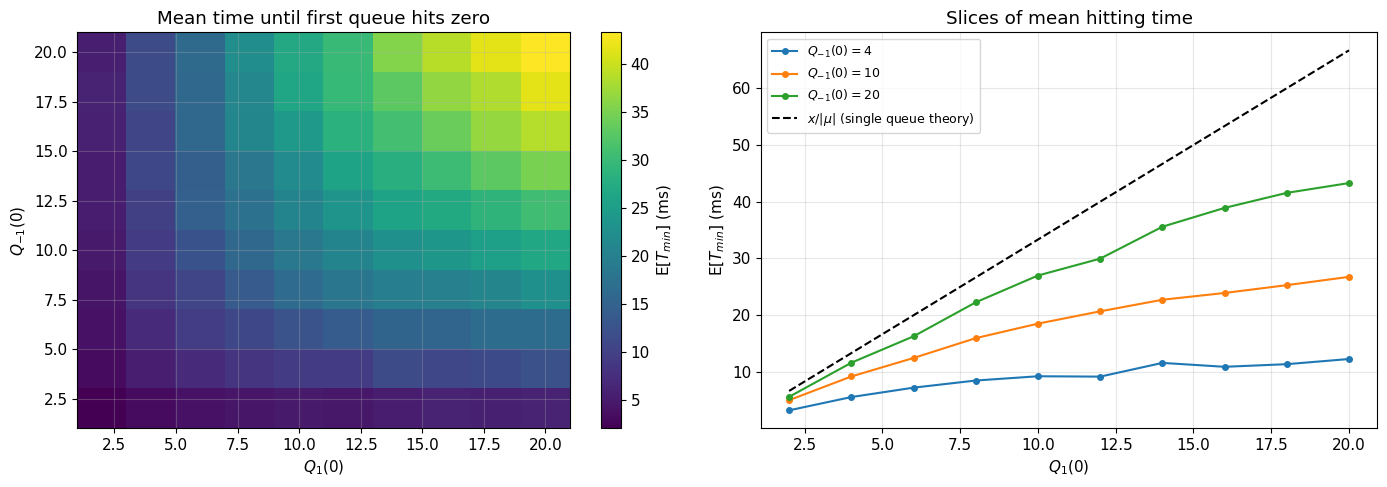

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: heatmap of E[T_min]
ax = axes[0]
im = ax.imshow(scan['mean_T_grid'], origin='lower', aspect='auto',
               extent=[q_range[0]-1, q_range[-1]+1, q_range[0]-1, q_range[-1]+1],
               cmap='viridis')
plt.colorbar(im, ax=ax, label='E[$T_{min}$] (ms)')
ax.set_xlabel('$Q_1(0)$')
ax.set_ylabel('$Q_{-1}(0)$')
ax.set_title('Mean time until first queue hits zero')

# Theoretical overlay: E[T_min] ≈ min(x1, x2) / |μ| for large values
# (rough approximation: T_min ≈ driven by the smaller queue)

# Right: 1D slices
ax = axes[1]
mid_idx = len(q_range) // 2
for j, q_neg1 in enumerate([4, 10, 20]):
    idx_j = np.argmin(np.abs(q_range - q_neg1))
    ax.plot(q_range, scan['mean_T_grid'][idx_j, :], 'o-', ms=4,
            label=f'$Q_{{-1}}(0) = {q_range[idx_j]}$')
# Theory: E[T_one] = x / |μ|
ax.plot(q_range, q_range / abs(MU), 'k--', lw=1.5,
        label=f'$x/|\\mu|$ (single queue theory)')
ax.set_xlabel('$Q_1(0)$')
ax.set_ylabel('E[$T_{min}$] (ms)')
ax.set_title('Slices of mean hitting time')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

## Q5. Probability that $Q_1$ hits zero before $Q_{-1}$

By symmetry, when $Q_1(0) = Q_{-1}(0)$, we expect $P(Q_1 \text{ first}) = 0.5$.  
When $Q_1(0) < Q_{-1}(0)$ (ask queue starts smaller), $Q_1$ is more likely to hit zero first.  

**Theoretical formula** (independent Brownian motions with same drift/diffusion):  
$$P(T_1 < T_2) = \int_0^\infty f_{T_1}(t) \cdot [1 - F_{T_2}(t)]\, dt$$

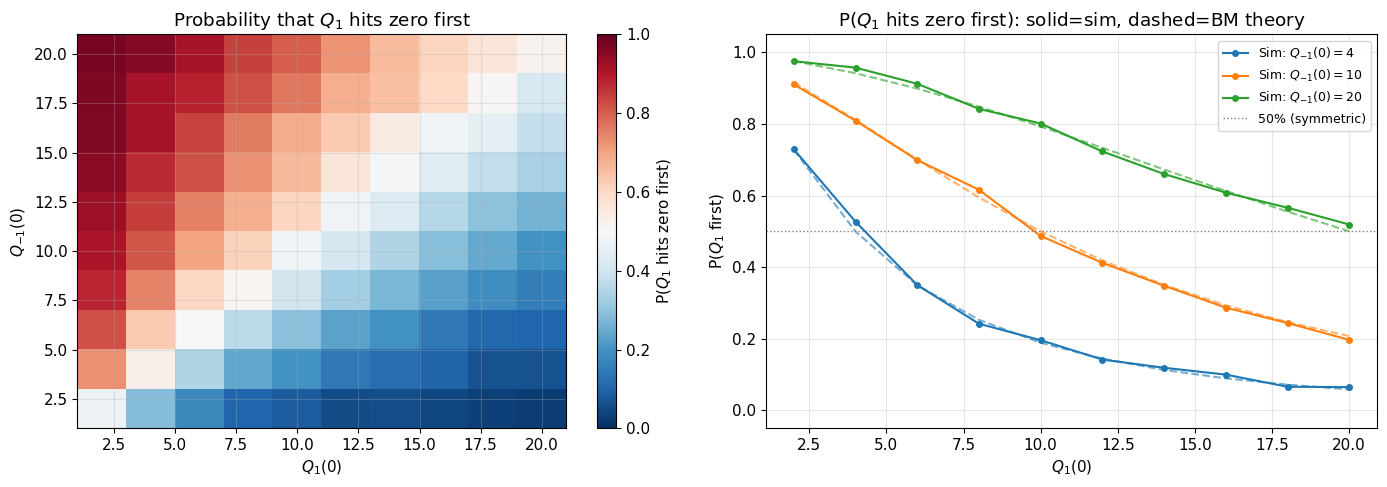

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: heatmap of P(Q1 first)
ax = axes[0]
im = ax.imshow(scan['prob_q1_grid'], origin='lower', aspect='auto',
               extent=[q_range[0]-1, q_range[-1]+1, q_range[0]-1, q_range[-1]+1],
               cmap='RdBu_r', vmin=0, vmax=1)
plt.colorbar(im, ax=ax, label='P($Q_1$ hits zero first)')
ax.set_xlabel('$Q_1(0)$')
ax.set_ylabel('$Q_{-1}(0)$')
ax.set_title('Probability that $Q_1$ hits zero first')

# Right: 1D slices + BM theory
ax = axes[1]
for j, q_neg1 in enumerate([4, 10, 20]):
    idx_j = np.argmin(np.abs(q_range - q_neg1))
    ax.plot(q_range, scan['prob_q1_grid'][idx_j, :], 'o-', ms=4,
            label=f'Sim: $Q_{{-1}}(0)={q_range[idx_j]}$')
    # BM theory
    p_theory = [prob_q1_hits_first_brownian(float(x1), float(q_range[idx_j]), MU, SIGMA)
                for x1 in q_range]
    ax.plot(q_range, p_theory, '--', lw=1.5, color=f'C{j}', alpha=0.6)

ax.axhline(0.5, color='gray', ls=':', lw=1, label='50% (symmetric)')
ax.set_xlabel('$Q_1(0)$')
ax.set_ylabel('P($Q_1$ first)')
ax.set_title('P($Q_1$ hits zero first): solid=sim, dashed=BM theory')
ax.legend(fontsize=9)
ax.set_ylim(-0.05, 1.05)

plt.tight_layout()
plt.show()

## Summary of Results

| Question | Key Result |
|----------|------------|
| Q0 | Simulation works: path terminates when one queue reaches 0 |
| Q1 | BM approximation holds: $\mu = \lambda^+ - \lambda^-$, $\sigma^2 = \lambda^+ + \lambda^-$ (verified by E, Var) |
| Q2 | Hitting time distribution matches **Inverse Gaussian** $\frac{x_0}{\sigma\sqrt{2\pi t^3}}e^{-(x_0+\mu t)^2/(2\sigma^2 t)}$ |
| Q3 | $E[T_{\min}] \approx 18.9$ ms (95% CI from MC), less than $E[T_{one}] = x_0/|\mu| = 33.3$ ms |
| Q4 | $E[T_{\min}]$ increases with both $Q_1(0)$ and $Q_{-1}(0)$, dominated by the smaller queue |
| Q5 | $P(Q_1 \text{ first})$ decreases as $Q_1(0)$ increases; = 0.5 on the diagonal; matches BM theory |